In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from math import sqrt

from sklearn.metrics import (mean_squared_error as MSE, mean_absolute_error as MAE, r2_score as R2,
                             explained_variance_score as EVS)
from sklearn.preprocessing import StandardScaler

from keras.models import load_model

%load_ext autoreload
%autoreload 2

%matplotlib inline

plt.rcParams['figure.figsize'] = (10, 8)

Using TensorFlow backend.


In [3]:
with open('splitted_alldat.pkl', 'rb') as f:
    dictly = pickle.load(f)
    
x_train_ = dictly['x_train']
y_train = dictly['y_train']
x_val_ = dictly['x_dev']
y_val = dictly['y_dev']
x_test_ = dictly['x_test']
y_test = dictly['y_test']

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train_.astype(float))
x_val = scaler.transform(x_val_.astype(float))
x_test = scaler.transform(x_test_.astype(float))

# Convert to MJ
y_test *= (60/10**6)
y_val *= (60/10**6)
y_train *= (60/10**6)

In [4]:
def fraction_within_eps(y_true, y_pred, epsilon=0.5):
    # Number of days where abs(y_true - y_pred) < epsilon divided by total number of days
    
    count = np.sum(np.abs(y_true - y_pred) <= epsilon)
    return count / y_true.shape[0]

yt = np.array([10, 10, 10, 10, 10])
yp = np.array([9.2, 9.7, 10.3, 10.2, 11])
print(fraction_within_eps(yt, yp, 0.6))
FIE = fraction_within_eps

0.6


In [5]:
def concorr(x, y):
    # Return Lin's concordance correlation coefficient
    # x, y are numpy arrays
    
    xm = x.mean()
    ym = y.mean()
    xv = x.var()
    yv = y.var()
    xycov = np.sum((x-xm)*(y-ym)) / x.shape[0]
    lin = 2*xycov / (xv + yv + (xm - ym)**2)
    return lin

xx = np.random.randn(10)
yy = xx + 10
print('R2 corr coef is {} whereas concordance corr coef is {}'.format(R2(yy,xx), concorr(yy,xx)))

R2 corr coef is -138.2509985189342 whereas concordance corr coef is 0.014159191941796481


In [6]:
model = load_model('./Rads1/chain 2.h5')
p = model.predict( x_test, batch_size=32 )

OSError: Unable to open file (unable to open file: name = './Rads1/chain 2.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [6]:
print(y_test.shape)
print(p.shape)
print(FIE(y_test, p))
print(FIE(y_test, np.squeeze(p)))
print(MAE(y_test, p))
print(MAE(y_test, np.squeeze(p)))

(10601,)
(10601, 1)
351.7939817
0.239694368456
2.30757272371
2.30757272371


In [7]:
rads = ['Rads1', 'Rads2', 'Rads4', 'Rads8', 'Rads16']
metrics = {}
metrics_train = {}
metrics_val = {}
for rad in rads:
    metrics[rad] = []
    metrics_train[rad] = []
    metrics_val[rad] = []
    print('Evaluating metrics for {}\n'.format(rad))
    for i in range(50):
        modelname = './{}/chain {}.h5'.format(rad, i+1)
        model = load_model(modelname)
        
        # predict on test set and evaluate the metrics
        p = model.predict( x_test, batch_size=32 )
        mse = MSE( y_test, p )
        rmse = sqrt( mse )
        mae = MAE( y_test, p )
        r2 = R2( y_test, p )
        evs = EVS( y_test, p )
        fie_h = FIE( y_test, np.squeeze(p), 0.5)
        fie_o = FIE( y_test, np.squeeze(p), 1)
        fie_oh = FIE( y_test, np.squeeze(p), 1.5)
        lin = concorr(y_test, np.squeeze(p))
        
        metrics[rad].append((rmse, mae, r2, evs, fie_h, fie_o, fie_oh, lin))
        
        print('C{:02d} » RMSE: {:.4f}, MAE: {:.4f}, R2: {:.4f}, EVS: {:.4f}, '
              'FIE_H: {:.4f}, FIE_O: {:.4f}, FIE_OH: {:.4f}, LINCC: {:.4f}'.format(i+1,
                                                            rmse, mae, r2, evs, fie_h, fie_o, fie_oh, lin))
        
        # Validation set
        p = model.predict( x_val, batch_size=32 )
        mse = MSE( y_val, p )
        rmse = sqrt( mse )
        mae = MAE( y_val, p )
        r2 = R2( y_val, p )
        evs = EVS( y_val, p )
        fie_h = FIE( y_val, np.squeeze(p), 0.5)
        fie_o = FIE( y_val, np.squeeze(p), 1)
        fie_oh = FIE( y_val, np.squeeze(p), 1.5)
        lin = concorr(y_val, np.squeeze(p))
        
        metrics_val[rad].append((rmse, mae, r2, evs, fie_h, fie_o, fie_oh, lin))
        
        print('C{:02d} » RMSE: {:.4f}, MAE: {:.4f}, R2: {:.4f}, EVS: {:.4f}, '
              'FIE_H: {:.4f}, FIE_O: {:.4f}, FIE_OH: {:.4f}, LINCC: {:.4f}'.format(i+1,
                                                            rmse, mae, r2, evs, fie_h, fie_o, fie_oh, lin))
        
        # Training set
        p = model.predict( x_train, batch_size=32 )
        mse = MSE( y_train, p )
        rmse = sqrt( mse )
        mae = MAE( y_train, p )
        r2 = R2( y_train, p )
        evs = EVS( y_train, p )
        fie_h = FIE( y_train, np.squeeze(p), 0.5)
        fie_o = FIE( y_train, np.squeeze(p), 1)
        fie_oh = FIE( y_train, np.squeeze(p), 1.5)
        lin = concorr(y_train, np.squeeze(p))
        
        metrics_train[rad].append((rmse, mae, r2, evs, fie_h, fie_o, fie_oh, lin))
        
        print('C{:02d} » RMSE: {:.4f}, MAE: {:.4f}, R2: {:.4f}, EVS: {:.4f}, '
              'FIE_H: {:.4f}, FIE_O: {:.4f}, FIE_OH: {:.4f}, LINCC: {:.4f}'.format(i+1,
                                                            rmse, mae, r2, evs, fie_h, fie_o, fie_oh, lin))

Evaluating metrics for Rads1

C01 » RMSE: 4.4220, MAE: 2.3747, R2: 0.7409, EVS: 0.7644, FIE_H: 0.2426, FIE_O: 0.4465, FIE_OH: 0.5902, LINCC: 0.8584
C01 » RMSE: 2.4389, MAE: 1.5567, R2: 0.9167, EVS: 0.9186, FIE_H: 0.2614, FIE_O: 0.4711, FIE_OH: 0.6291, LINCC: 0.9554
C01 » RMSE: 2.8822, MAE: 1.6338, R2: 0.8862, EVS: 0.8862, FIE_H: 0.2705, FIE_O: 0.4943, FIE_OH: 0.6614, LINCC: 0.9391
C02 » RMSE: 4.3003, MAE: 2.3076, R2: 0.7550, EVS: 0.7715, FIE_H: 0.2397, FIE_O: 0.4532, FIE_OH: 0.6021, LINCC: 0.8673
C02 » RMSE: 2.4717, MAE: 1.6140, R2: 0.9145, EVS: 0.9188, FIE_H: 0.2335, FIE_O: 0.4480, FIE_OH: 0.6013, LINCC: 0.9547
C02 » RMSE: 2.9161, MAE: 1.6610, R2: 0.8835, EVS: 0.8838, FIE_H: 0.2572, FIE_O: 0.4784, FIE_OH: 0.6506, LINCC: 0.9384
C03 » RMSE: 4.4404, MAE: 2.3778, R2: 0.7388, EVS: 0.7599, FIE_H: 0.2461, FIE_O: 0.4407, FIE_OH: 0.5909, LINCC: 0.8590
C03 » RMSE: 2.4707, MAE: 1.6204, R2: 0.9145, EVS: 0.9182, FIE_H: 0.2209, FIE_O: 0.4367, FIE_OH: 0.6067, LINCC: 0.9547
C03 » RMSE: 2.9170, MAE: 1

In [8]:
metric_results = {'train':metrics_train, 'val':metrics_val, 'test':metrics}
with open('metrics_full.pkl', 'wb') as f:
    pickle.dump(metric_results, f)

In [5]:
with open('metrics_full.pkl', 'rb') as f:
    metric_results = pickle.load(f)

#assert metric_results == metric_results2

metrics_train = metric_results['train']
metrics_dev = metric_results['val']
metrics_test = metric_results['test']

In [6]:
# let's get the data ready for boxplot
# I want 5 boxes, RMSE of Rads1 - Rads2 - Rads4 - Rads8 - Rads16
# other metrics as well
my_measures = ['rmse', 'mae', 'r2', 'evs', 'fie_h', 'fie_o', 'fie_oh', 'lin']
m_i = {}
n = 0
#rmse_vals = {}
suffix = {'train':'_train', 'dev':'_dev', 'test':'_test'}
for m in my_measures:
    m_i[m] = n
    n += 1
    for s in suffix:
        exec(f'{m}_vals{suffix[s]} = {{}}')

#rmse_vals, mae_vals, r2_vals, evs_vals = {}, {}, {}, {}

#_ = [exec('{}_vals{suffix[s]}[key] = np.array(metrics[key])[:,m_i[m]]'.format(m)) for m in my_measures for key in metrics_test for s in suffix]
for s in suffix:
    for key in metrics_test:
        for m in my_measures:
            exec(f'{m}_vals{suffix[s]}[key] = np.array(metrics{suffix[s]}[key])[:,m_i[m]]')
#for key in metrics:
#    [eval('{}_vals[key] = np.array(metrics[key])[:,m_i[m]]'.format(m)) for m in my_measures]
    #rmse_vals[key] = np.array(metrics[key])[:,0]
    #mae_vals[key] = np.array(metrics[key])[:,1]
    #r2_vals[key] = np.array(metrics[key])[:,2]
    #evs_vals[key] = np.array(metrics[key])[:,3]

In [8]:
#_ = [exec(f'{m} = []') for m in my_measures]
for s in suffix:
    for m in my_measures:
        exec(f'{m}{suffix[s]} = []')

_ = [exec(f'{m}{suffix[s]}.append({m}_vals{suffix[s]}[key])') for key in metrics_test for m in my_measures for s in suffix]
labels = [key for key in rmse_vals_train]
#rmses, maes, r2s, evss = [], [], [], []
#labels = []
#for key in rmse_vals:
#    rmses.append(rmse_vals[key])
#    maes.append(mae_vals[key])
#    r2s.append(r2_vals[key])
#    evss.append(evs_vals[key])
#    labels.append(key)

{'Rads1': array([ 2.88215492,  2.9160852 ,  2.91704578,  2.88077075,  2.79908269,
        2.8837117 ,  2.87586425,  2.84934608,  2.85054225,  2.80854145,
        2.80999075,  2.84297955,  2.86652255,  2.87179486,  2.81820295,
        2.81187562,  2.82557805,  2.91224373,  2.78223561,  2.87063316,
        2.88360186,  2.86906516,  2.83044382,  2.83240734,  2.93271236,
        2.81546552,  2.8301782 ,  2.81921253,  2.99034862,  2.93196999,
        2.82518876,  2.85070005,  2.90378044,  2.8508826 ,  2.83087852,
        2.78769327,  2.88301177,  2.83994585,  2.87684877,  2.84069456,
        2.9217059 ,  2.82261497,  2.99965309,  2.87811887,  2.93173396,
        2.91543749,  2.90660067,  2.85353137,  2.85543992,  2.90230273]), 'Rads2': array([ 2.84461338,  2.78767067,  2.87736063,  2.8241472 ,  2.80315185,
        2.84889513,  2.89023754,  2.84024706,  2.80478309,  2.84629243,
        2.96121373,  2.7865166 ,  2.85606892,  2.77755801,  2.89568001,
        2.86135162,  2.83010861,  2.8844331

TypeError: unsupported operand type(s) for /: 'dict' and 'int'

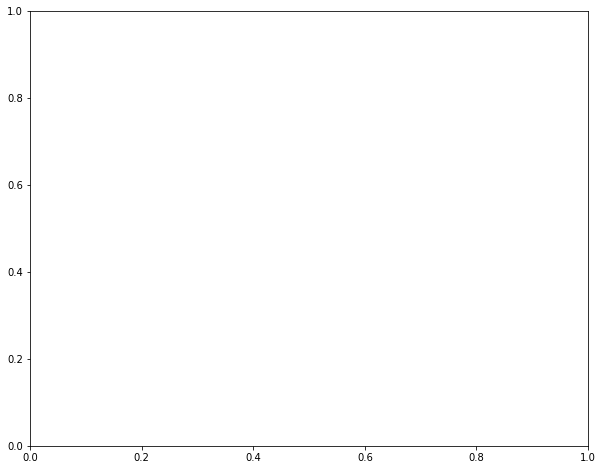

In [10]:
#print(list(rmse_vals_train[key] for key in rmse_vals_train))
print(rmse_vals_train)
plt.boxplot(rmse_vals_train)

/home/bulent/anaconda3/lib/python3.6/site-packages/matplotlib/pyplot.py:523: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  max_open_warning, RuntimeWarning)


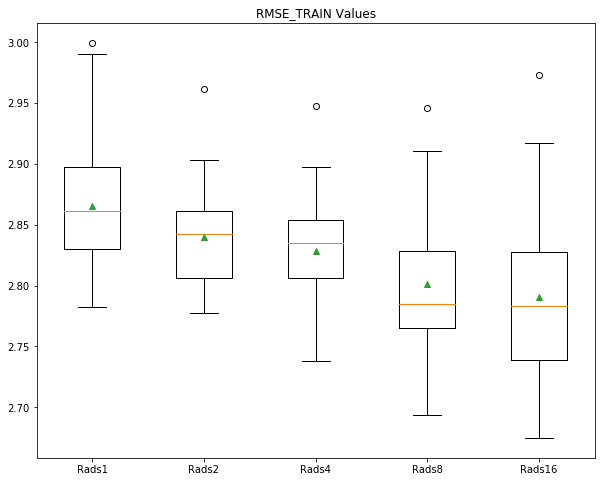

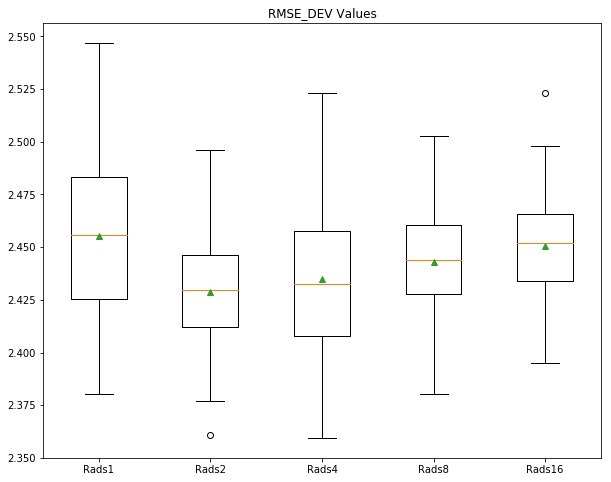

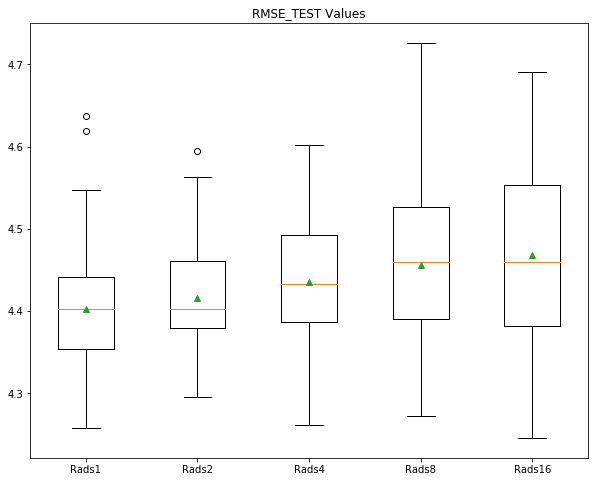

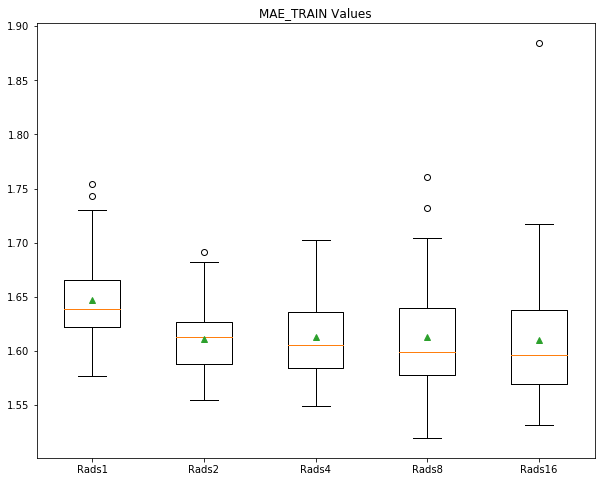

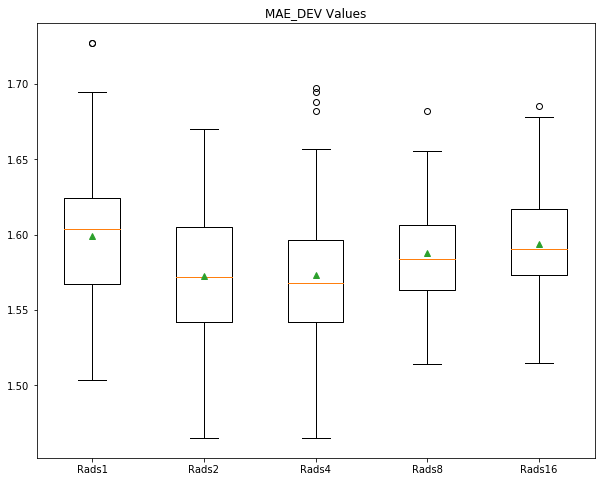

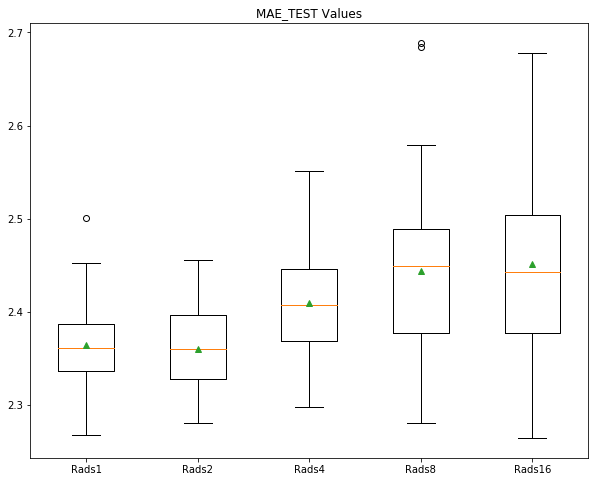

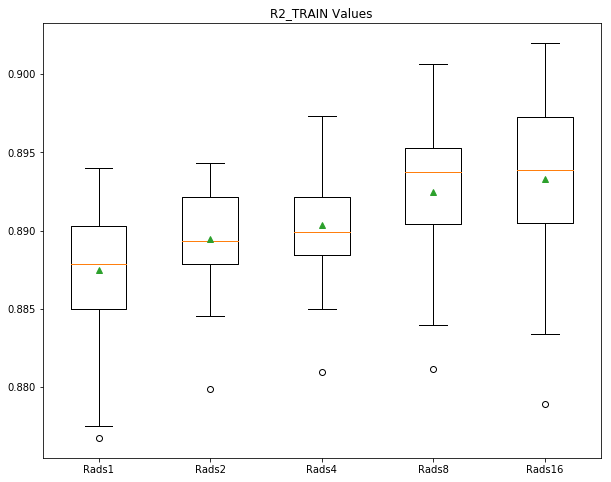

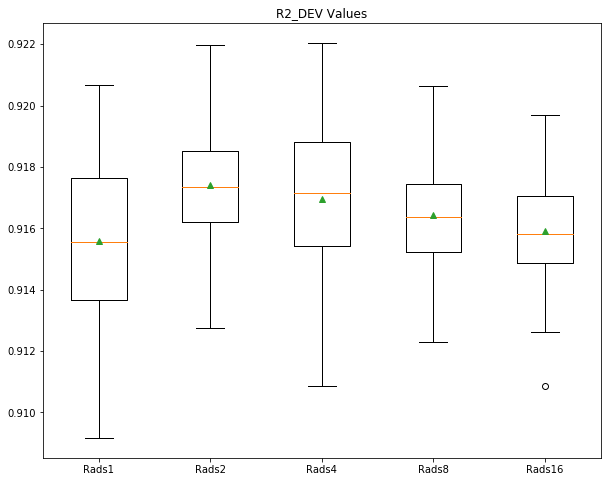

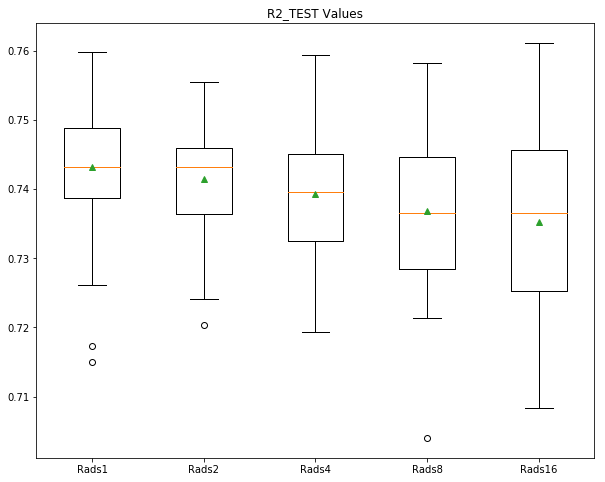

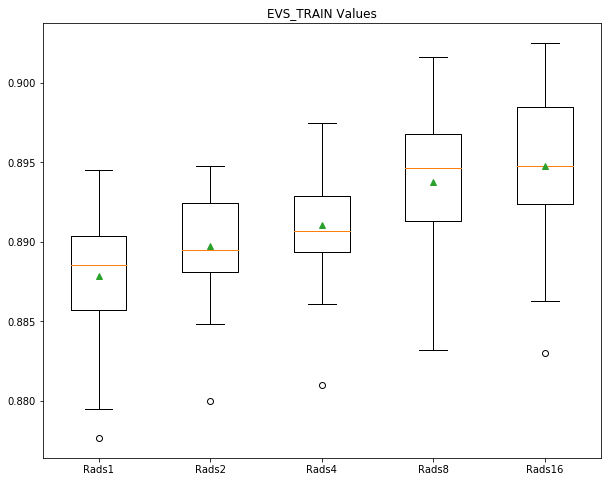

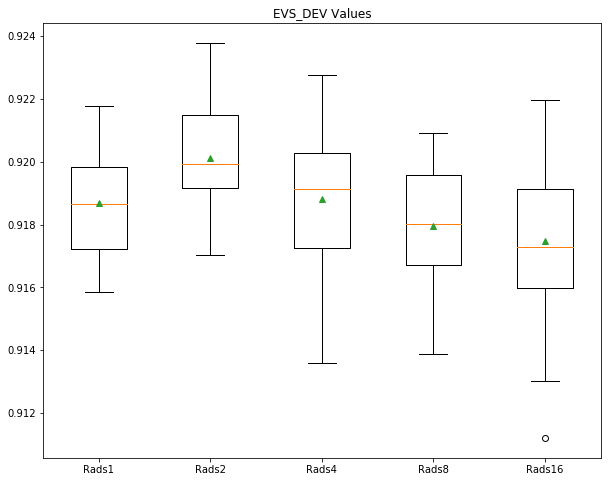

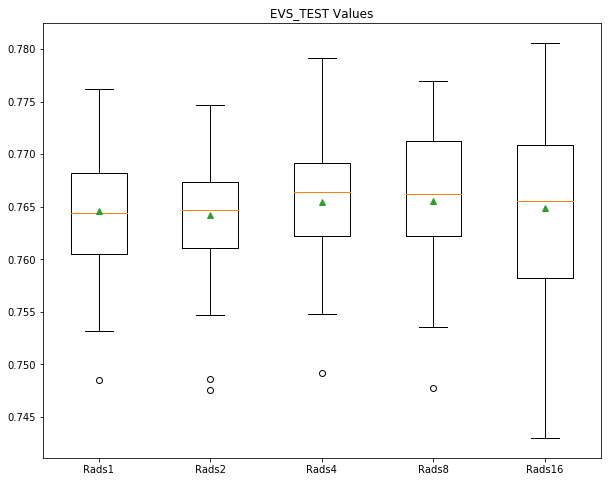

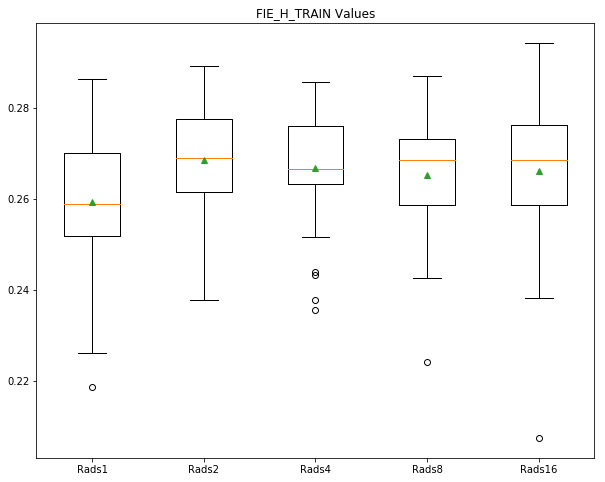

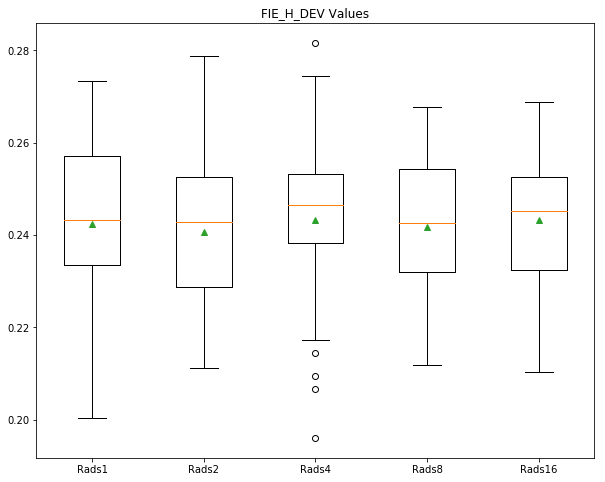

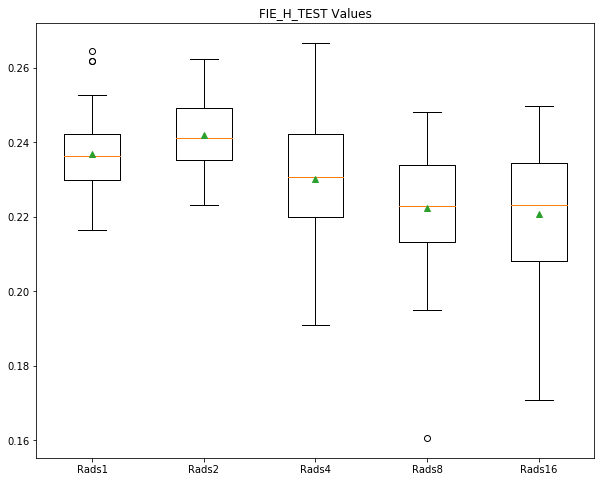

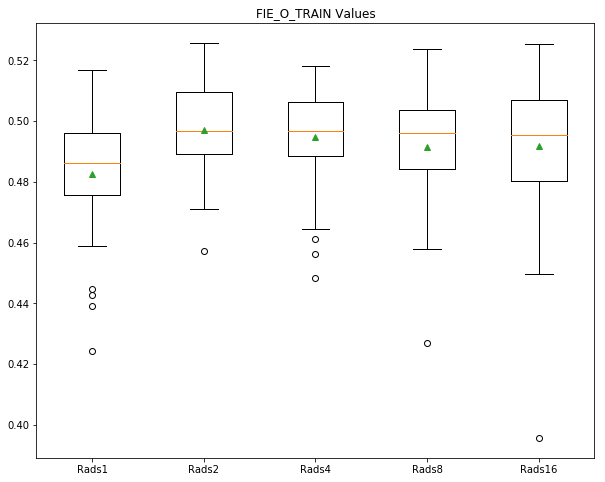

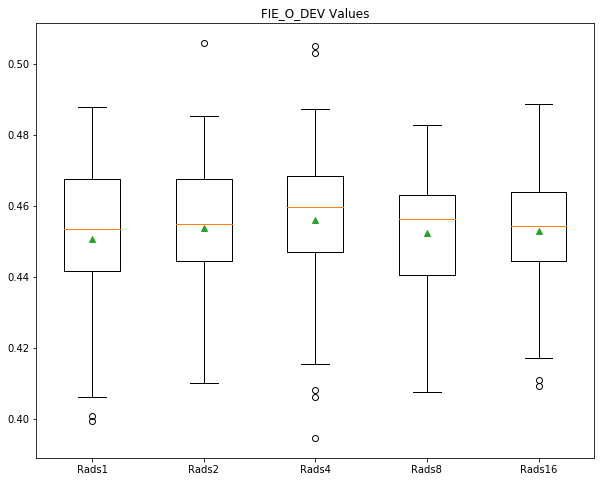

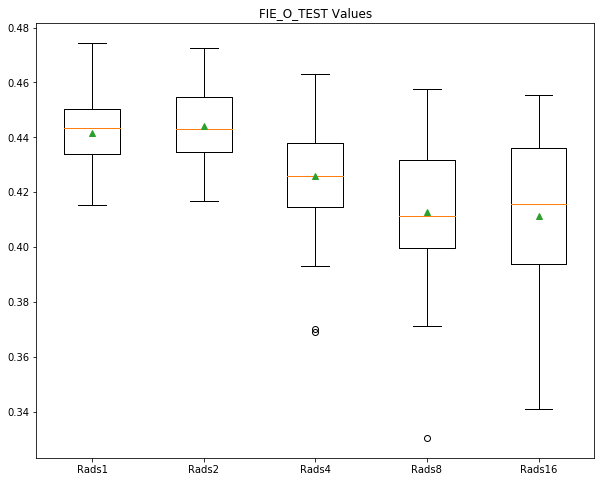

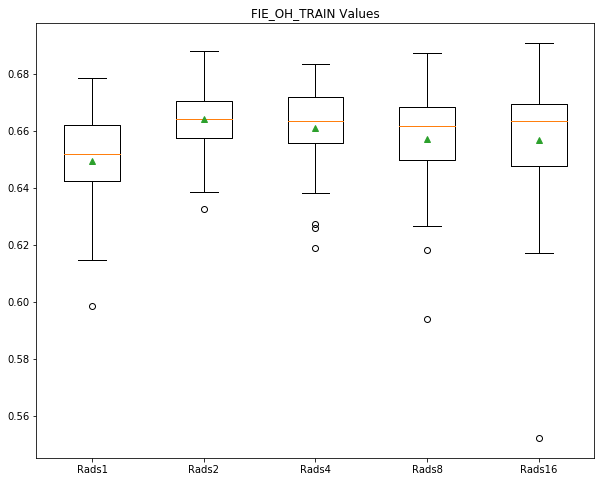

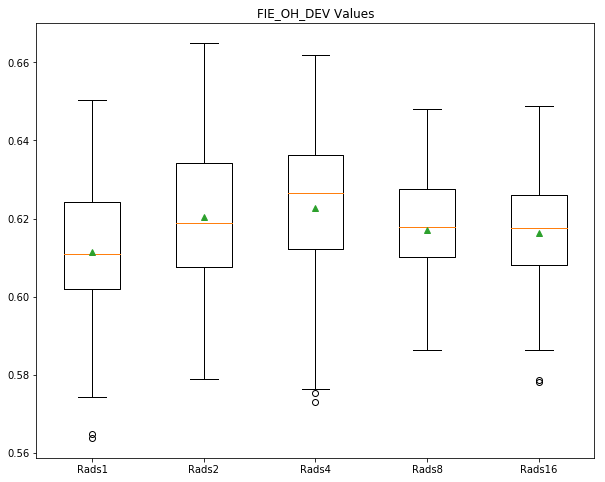

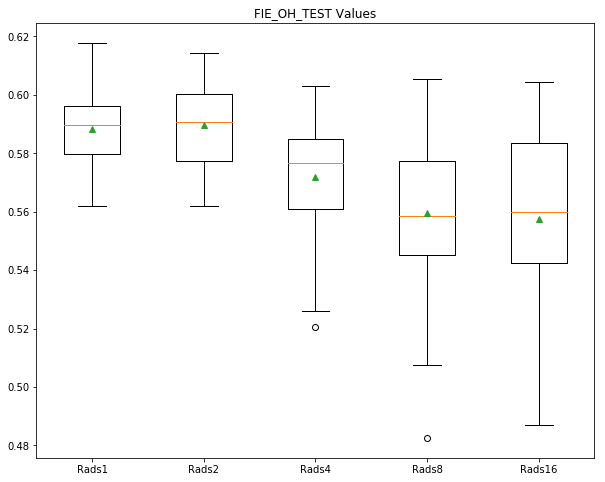

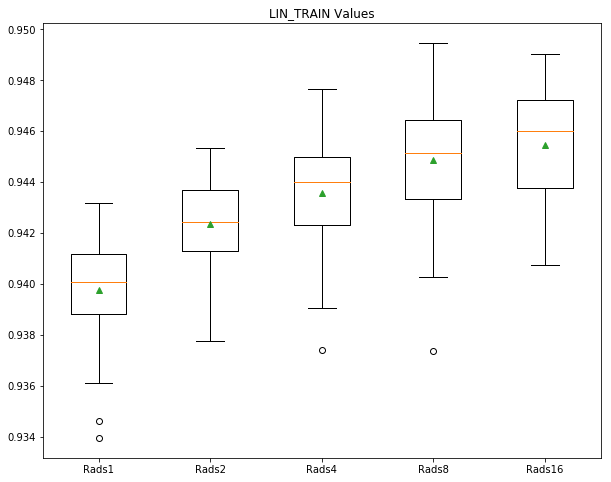

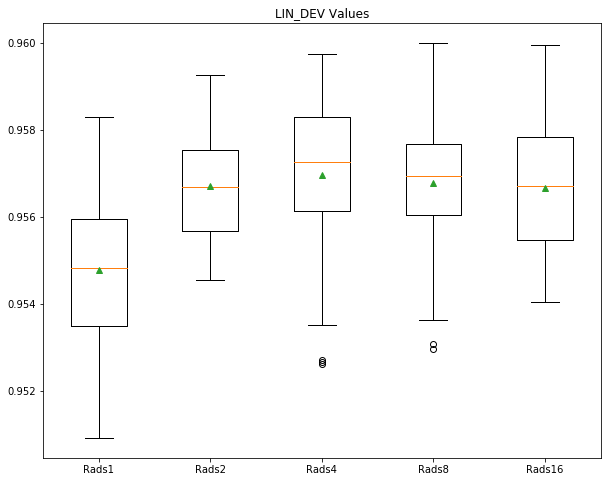

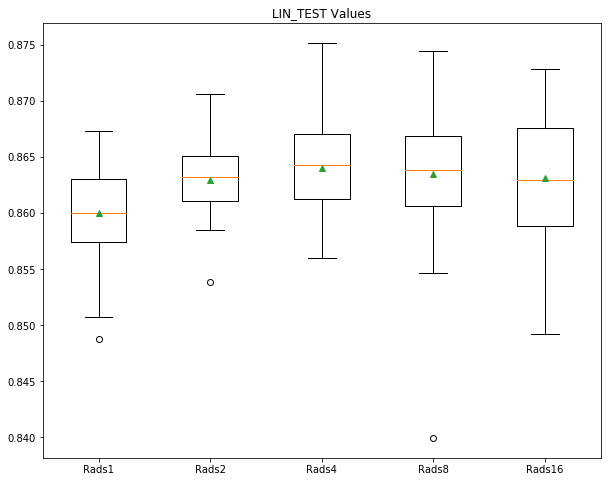

In [13]:
fignum = 1
for m in my_measures:
    for s in suffix:
        plt.figure(fignum)
        plt.title(f'{m}{suffix[s]}'.upper()+' Values')
        _ = exec(f'plt.boxplot({m}{suffix[s]}, labels=labels, showmeans=True)')
        fignum += 1
# plt.figure(1)
# plt.title('RMSE Values')
# plt.boxplot(rmse, labels=labels)

# plt.figure(2)
# plt.title('MAE Values')
# plt.boxplot(mae, labels=labels)

# plt.figure(3)
# plt.title('R2 Values')
# plt.boxplot(r2, labels=labels)

# plt.figure(4)
# plt.title('EVS Values')
# plt.boxplot(evs, labels=labels)

In [8]:
def quadratic(s):
    return 0.145 + 0.845*s - 0.280*s**2

#print(x_test_[5:10]) # - phi - n - T - N - H0 are the column order
h0 = x_test_[:, 4] / 1e6
s = x_test_[:, 1] / x_test_[:, 3]

p = h0 * quadratic(s)

mse = MSE( y_test, p )
rmse = sqrt( mse )
mae = MAE( y_test, p )
r2 = R2( y_test, p )
evs = EVS( y_test, p )
fie_h = FIE( y_test, p, 0.5 )
fie_o = FIE( y_test, p, 1 )
fie_oh = FIE( y_test, p, 1.5 )
concor = concorr(y_test, p )
print('« Quadratic in s with Test Set »\nRMSE: {:.4f}, MAE: {:.4f}, R2: {:.4f}, EVS: {:.4f}, '
              'FIE_H: {:.4f}, FIE_O: {:.4f}, FIE_OH: {:.4f}'.format(rmse, mae, r2, evs, fie_h, fie_o, fie_oh))
print(f'Lin\'s Concordance Correlation: {concor} ')

« Quadratic in s with Test Set »
RMSE: 4.1642, MAE: 2.2309, R2: 0.7702, EVS: 0.7706, FIE_H: 0.2312, FIE_O: 0.4275, FIE_OH: 0.5877
Lin's Concordance Correlation: 0.8770810714136482 


In [9]:
from scipy.optimize import curve_fit

def quadly(s, a, b, c):
    hh0 = a*s + b*s**2 + c
    return hh0

h0_train = x_train_[:, 4] / 1e6
s_train = x_train_[:, 1] / x_train_[:, 3]

popt, _ = curve_fit(quadly, s_train, y_train/h0_train)

p = h0 * quadly(s, *popt)

mse = MSE( y_test, p )
rmse = sqrt( mse )
mae = MAE( y_test, p )
r2 = R2( y_test, p )
evs = EVS( y_test, p )
fie_h = FIE( y_test, p, 0.5 )
fie_o = FIE( y_test, p, 1 )
fie_oh = FIE( y_test, p, 1.5 )
concor = concorr( y_test, p )
print('« Quadratic in s,Tavg with Test Set »\nRMSE: {:.4f}, MAE: {:.4f}, R2: {:.4f}, EVS: {:.4f}, '
              'FIE_H: {:.4f}, FIE_O: {:.4f}, FIE_OH: {:.4f}'.format(rmse, mae, r2, evs, fie_h, fie_o, fie_oh))
print(f'Lin\'s Concordance Correlation: {concor} ')

« Quadratic in s,Tavg with Test Set »
RMSE: 4.3747, MAE: 2.3738, R2: 0.7464, EVS: 0.7730, FIE_H: 0.2240, FIE_O: 0.4264, FIE_OH: 0.5796
Lin's Concordance Correlation: 0.8618908980982593 


In [22]:
import pandas as pd

testey = pd.DataFrame([h0, s, y_test]).T
trainey = pd.DataFrame([h0_train, s_train, y_train]).T

print(trainey.head(10))

with pd.ExcelWriter('excelify.xlsx') as writer:
    trainey.to_excel(writer, sheet_name='train')
    testey.to_excel(writer, sheet_name='test')

           0         1         2
0  13.136193  0.010989  1.978836
1  13.189443  0.263399  5.054568
2  13.247742  0.526059  5.950866
3  13.311073  0.372059  4.479732
4  13.379415  0.109250  2.604840
5  13.452745  0.076342  2.883132
6  13.531038  0.108857  4.390644
7  13.614268  0.065186  2.941080
8  13.702405  0.000000  2.429136
9  13.795420  0.075727  4.009044


In [25]:
def excelified(s):
    return -0.07793*s**2 + 0.574988*s + 0.256497

p = h0 * excelified(s)

mse = MSE( y_test, p )
rmse = sqrt( mse )
mae = MAE( y_test, p )
r2 = R2( y_test, p )
evs = EVS( y_test, p )
fie_h = FIE( y_test, p, 0.5 )
fie_o = FIE( y_test, p, 1 )
fie_oh = FIE( y_test, p, 1.5 )
concor = concorr(y_test, p )
print('« Quadratic in s with Test Set »\nRMSE: {:.4f}, MAE: {:.4f}, R2: {:.4f}, EVS: {:.4f}, '
              'FIE_H: {:.4f}, FIE_O: {:.4f}, FIE_OH: {:.4f}'.format(rmse, mae, r2, evs, fie_h, fie_o, fie_oh))
print(f'Lin\'s Concordance Correlation: {concor} ')

« Quadratic in s with Test Set »
RMSE: 4.3747, MAE: 2.3738, R2: 0.7464, EVS: 0.7730, FIE_H: 0.2241, FIE_O: 0.4264, FIE_OH: 0.5796
Lin's Concordance Correlation: 0.861891014392809 


In [10]:
def wololo(xdata, a, b, c, d, e):
    # xdata must be a tuple
    s, tavg = xdata
    # a*T + b*T^2 + c*s + d*s^2 + e
    hh0 = a * tavg + b * tavg ** 2 + c * s + d * s ** 2 + e
    return hh0

h0_train = x_train_[:, 4] / 1e6
s_train = x_train_[:, 1] / x_train_[:, 3]
tavg_train = x_train_[:, 2]
xdat_train = (s_train, tavg_train)

popt, _ = curve_fit(wololo, xdat_train, y_train/h0_train)

tavg = x_test_[:, 2]
xdat = (s, tavg)
p = h0 * wololo(xdat, *popt)

mse = MSE( y_test, p )
rmse = sqrt( mse )
mae = MAE( y_test, p )
r2 = R2( y_test, p )
evs = EVS( y_test, p )
fie_h = FIE( y_test, p, 0.5 )
fie_o = FIE( y_test, p, 1 )
fie_oh = FIE( y_test, p, 1.5 )
concor = concorr( y_test, p )
print('« Quadratic in s,Tavg with Test Set »\nRMSE: {:.4f}, MAE: {:.4f}, R2: {:.4f}, EVS: {:.4f}, '
              'FIE_H: {:.4f}, FIE_O: {:.4f}, FIE_OH: {:.4f}'.format(rmse, mae, r2, evs, fie_h, fie_o, fie_oh))
print(f'Lin\'s Concordance Correlation: {concor} ')

« Quadratic in s,Tavg with Test Set »
RMSE: 4.3230, MAE: 2.3322, R2: 0.7524, EVS: 0.7763, FIE_H: 0.2292, FIE_O: 0.4380, FIE_OH: 0.5930
Lin's Concordance Correlation: 0.8636772122681948 


In [9]:
sun_quad_std = np.std(h0 * quadratic(s))
sun_temp_quad_std = np.std(h0 * wololo(xdat, *popt))
print('Stdev of s/S model: {}, of s/S and T_avg model: {}'.format(sun_quad_std, sun_temp_quad_std))

Stdev of s/S model: 8.289810672964727, of s/S and T_avg model: 7.823940805206789


In [29]:
def stderr(x, error_rate):
    # Calculate the absolute +/- error value from the error rate
    # x is a numpy array
    
    return x*error_rate

print('{} +/- {}'.format(y_test[0], stderr(y_test, 0.02)[:20]))

12.956766000000002 +/- [ 0.25913532  0.4313202   0.040251    0.47718312  0.12944472  0.41838336
  0.2649096   0.50083332  0.0533658   0.28774908  0.02800776  0.29931024
  0.40737348  0.55982028  0.46090224  0.0900996   0.0768864   0.27977076
  0.20130888  0.5687034 ]


In [17]:
def sumprop(errors, values=None):
    # given an array of errors, calculate their propogation
    if values is None:
        return np.sqrt(np.sum(errors ** 2))
    else:
        return np.sqrt(np.sum(errors ** 2)) / np.sum(values)
print('sumprop of y_test: {}'.format(sumprop(stderr(y_test, 0.02))))

sumprop of y_test: 32.16402234713284


In [8]:
p_s = h0 * quadratic(s)
p_st = h0 * wololo(xdat, *popt)
print('Concordance Corr b/w s only model and s,T model: {}'.format(concorr(p_s, p_st)))

Concordance Corr b/w s only model and s,T model: 0.9669769506158622


In [9]:
ann = load_model('./Rads1/chain 2.h5')
p_ann = ann.predict( x_test, batch_size=32 )
print('Concordance Corr b/w ANN model and s only model: {}'.format(concorr(p_ann, p_s)))
print('Concordance Corr b/w ANN model and s,T model: {}'.format(concorr(p_ann, p_st)))
print('Concordance Corr b/w ANN model and y_test: {}'.format(concorr(p_ann, y_test)))
print('Concordance Corr b/w s only model and y_test: {}'.format(concorr(p_s, y_test)))
print('Concordance Corr b/w s,T model and y_test: {}'.format(concorr(p_st, y_test)))
print('Pearson R2 Corr b/w s only model and y_test: {}'.format(R2(p_s, y_test)))
print('Pearson R2 Corr b/w s,T model and y_test: {}'.format(R2(p_st, y_test)))
print('Pearson R2 Corr b/w ANN model and y_test: {}'.format(R2(p_ann, y_test)))

/home/bulent/anaconda3/lib/python3.6/site-packages/keras/models.py:291: UserWarning: Error in loading the saved optimizer state. As a result, your model is starting with a freshly initialized optimizer.
  warnings.warn('Error in loading the saved optimizer '


Concordance Corr b/w ANN model and s only model: -2.822840479417486e-17
Concordance Corr b/w ANN model and s,T model: 5.675036229811688e-17
Concordance Corr b/w ANN model and y_test: -2.505746851144886e-16
Concordance Corr b/w s only model and y_test: 0.9078755436819061
Concordance Corr b/w s,T model and y_test: 0.9313531997946793
Pearson R2 Corr b/w s only model and y_test: 0.8079865106033577
Pearson R2 Corr b/w s,T model and y_test: 0.8492404819005748
Pearson R2 Corr b/w ANN model and y_test: 0.8636141856638611


In [25]:
print(p_ann[12], p_s[12], p_st[12])

[ 21.39447212] 19.390991655 20.4268368636
